# NB4 (ML) Plan: Regime Detection + Rule-to-Portfolio Backtest

## Goal (what NB4 should prove)

Use ML to **discover market regimes** (risk-on / risk-off / transition) using BTC + S&P behavior, then turn regimes into a **simple, testable signal** (e.g., "dip-buy BTC" only in certain regimes) and **backtest** it vs strong baselines.

## 1) Data Inputs (from earlier notebooks)

In [21]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Load the cleaned data
PROCESSED_DATA_FILE = '../data/processed/btc_sp500_data.csv'
df = pd.read_csv(PROCESSED_DATA_FILE, index_col='Date', parse_dates=True)

# Rename columns for clarity
df.rename(columns={'BTC-USD': 'btc_price', '^GSPC': 'sp_price'}, inplace=True)

# Calculate daily returns
df['btc_ret'] = df['btc_price'].pct_change()
df['sp_ret'] = df['sp_price'].pct_change()

# Create a cash asset (0% return)
df['cash_ret'] = 0

# Drop missing values created by pct_change()
df.dropna(inplace=True)

df.head()

,btc_price,sp_price,btc_ret,sp_ret,cash_ret
Date,,,,,
2015-01-02,315.032013,2058.199951,0.002492,0.000000,0
2015-01-03,281.082001,2058.199951,-0.107767,0.000000,0
2015-01-04,264.195007,2058.199951,-0.060079,0.000000,0
2015-01-05,274.473999,2020.579956,0.038907,-0.018278,0
2015-01-06,286.188995,2002.609985,0.042682,-0.008893,0


## 2) Feature Engineering (make regimes explainable)

In [22]:
from sklearn.preprocessing import StandardScaler

# Define rolling window sizes
ROLLING_WINDOWS = [20, 60, 120]

features = pd.DataFrame(index=df.index)

for window in ROLLING_WINDOWS:
    # Rolling volatility
    features[f'roll_vol_btc_{window}'] = df['btc_ret'].rolling(window=window).std()
    features[f'roll_vol_sp_{window}'] = df['sp_ret'].rolling(window=window).std()

    # Rolling return / momentum
    features[f'mom_btc_{window}'] = df['btc_ret'].rolling(window=window).mean()
    features[f'mom_sp_{window}'] = df['sp_ret'].rolling(window=window).mean()

    # Rolling correlation of returns
    features[f'corr_{window}'] = df['btc_ret'].rolling(window=window).corr(df['sp_ret'])

# Drawdown features
def calculate_drawdown(prices):
    rolling_max = prices.cummax()
    drawdown = (prices - rolling_max) / rolling_max
    return drawdown

features['dd_btc'] = calculate_drawdown(df['btc_price'])
features['dd_sp'] = calculate_drawdown(df['sp_price'])

# Relative strength
for window in ROLLING_WINDOWS:
    features[f'relative_strength_{window}'] = features[f'mom_btc_{window}'] - features[f'mom_sp_{window}']

# "BTC as proxy" indicator
for window in ROLLING_WINDOWS:
    features[f'btc_proxy_{window}'] = features[f'roll_vol_btc_{window}'] / features[f'roll_vol_sp_{window}']

# Drop NaNs created by rolling windows
features.dropna(inplace=True)

# Align features with the original dataframe
df_aligned = df.loc[features.index].copy()

# Normalize features
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

X.head()

,roll_vol_btc_20,roll_vol_sp_20,mom_btc_20,mom_sp_20,corr_20,roll_vol_btc_60,roll_vol_sp_60,mom_btc_60,mom_sp_60,corr_60,...,mom_sp_120,corr_120,dd_btc,dd_sp,relative_strength_20,relative_strength_60,relative_strength_120,btc_proxy_20,btc_proxy_60,btc_proxy_120
Date,,,,,,,,,,,,,,,,,,,,,
2015-05-01,-0.283779,-0.414067,-0.336045,-0.100225,-0.958551,-0.377492,-0.346959,-0.901104,-0.409700,-1.012993,...,-0.205042,-0.726128,0.299744,0.738091,-0.328523,-0.871209,-0.947702,-0.108090,-0.194197,0.616759
2015-05-02,-0.273935,-0.414067,-0.250942,-0.100225,-0.958820,-0.386704,-0.352497,-0.932386,-0.332206,-0.969298,...,-0.205042,-0.726455,0.335722,0.738091,-0.239307,-0.919991,-0.925373,-0.102290,-0.194027,0.617486
2015-05-03,-0.414425,-0.434930,0.188125,0.023168,-1.330800,-0.390747,-0.357873,-0.757441,-0.257274,-1.023584,...,-0.205042,-0.727017,0.404221,0.738091,0.191724,-0.749918,-0.626975,-0.165005,-0.191145,0.570978
2015-05-04,-0.463787,-0.430565,0.301385,0.058478,-1.339641,-0.394683,-0.356015,-0.812449,-0.227485,-1.033954,...,-0.164526,-0.729839,0.387311,0.787724,0.302087,-0.814177,-0.509407,-0.198851,-0.195095,0.554056
2015-05-05,-0.467711,-0.333079,0.097649,-0.399015,-1.150020,-0.394880,-0.372833,-0.811179,-0.187588,-1.049783,...,-0.075787,-0.611001,0.350752,0.587350,0.196967,-0.820896,-0.640439,-0.284536,-0.179001,0.587045


## 3) ML Step: Unsupervised Regime Discovery (the "ML")

In [23]:
from hmmlearn.hmm import GaussianHMM
from sklearn.cluster import KMeans

# A) Primary: Hidden Markov Model (HMM) (3–5 states)
N_REGIMES = 4
hmm = GaussianHMM(n_components=N_REGIMES, covariance_type='full', n_iter=100, random_state=42)
hmm.fit(X)
hmm_regimes = hmm.predict(X)

# B) Sanity check: K-Means clustering (same # of clusters)
kmeans = KMeans(n_clusters=N_REGIMES, random_state=42, n_init=10)
kmeans_regimes = kmeans.fit_predict(X)

# Add regimes to the dataframe
df_aligned['hmm_regime'] = hmm_regimes
df_aligned['kmeans_regime'] = kmeans_regimes

# Regime summary table
regime_summary = df_aligned.groupby('hmm_regime')[['btc_ret', 'sp_ret']].mean() * 252 # Annualized returns
regime_summary['BTC Volatility'] = df_aligned.groupby('hmm_regime')['btc_ret'].std() * np.sqrt(252) # Annualized volatility
regime_summary['SP500 Volatility'] = df_aligned.groupby('hmm_regime')['sp_ret'].std() * np.sqrt(252) # Annualized volatility

regime_summary

Model is not converging.  Current: 30460.462632171086 is not greater than 82176.7319451746. Delta is -51716.26931300352


,btc_ret,sp_ret,BTC Volatility,SP500 Volatility
hmm_regime,,,,
0,0.425794,0.078632,0.488075,0.118317
1,1.820997,0.090584,0.843017,0.081373
2,0.058664,0.142380,0.617430,0.315195
3,0.484461,0.215270,0.513587,0.036225


## 4) Turn Regimes into a Signal (no forecasting)

In [24]:
# Option 1: "Dip-buy BTC only in good regimes"
# Identify good regimes based on the summary table
# For example, let's assume regime 0 and 2 are 'good' regimes with high BTC returns.
GOOD_REGIMES = [0, 2] # This should be based on the analysis of the regime_summary table
DIP_THRESHOLD = -0.1 # Buy BTC if drawdown is more than 10%

df_aligned['dip_buy_signal'] = 0
dip_buy_conditions = (df_aligned['hmm_regime'].isin(GOOD_REGIMES)) & (features['dd_btc'] < DIP_THRESHOLD)
df_aligned.loc[dip_buy_conditions, 'dip_buy_signal'] = 1

# Option 2: Dynamic allocation weights (BTC / SP / Cash)
allocation_weights = {
    0: {'BTC': 0.7, 'SP': 0.3, 'Cash': 0.0}, # Risk-on
    1: {'BTC': 0.3, 'SP': 0.7, 'Cash': 0.0}, # Neutral
    2: {'BTC': 0.0, 'SP': 0.5, 'Cash': 0.5}, # Risk-off
    3: {'BTC': 0.5, 'SP': 0.0, 'Cash': 0.5}  # BTC-specific risk
} # This is an example, the weights should be defined based on regime characteristics

df_aligned['btc_weight'] = df_aligned['hmm_regime'].apply(lambda x: allocation_weights[x]['BTC'])
df_aligned['sp_weight'] = df_aligned['hmm_regime'].apply(lambda x: allocation_weights[x]['SP'])
df_aligned['cash_weight'] = df_aligned['hmm_regime'].apply(lambda x: allocation_weights[x]['Cash'])

df_aligned.head()

,btc_price,sp_price,btc_ret,sp_ret,cash_ret,hmm_regime,kmeans_regime,dip_buy_signal,btc_weight,sp_weight,cash_weight
Date,,,,,,,,,,,
2015-05-01,232.078995,2108.290039,-0.017218,0.010923,0,0,3,1,0.7,0.3,0.0
2015-05-02,234.929993,2108.290039,0.012285,0.000000,0,0,3,1,0.7,0.3,0.0
2015-05-03,240.358002,2108.290039,0.023105,0.000000,0,0,3,1,0.7,0.3,0.0
2015-05-04,239.018005,2114.489990,-0.005575,0.002941,0,0,3,1,0.7,0.3,0.0
2015-05-05,236.121002,2089.459961,-0.012120,-0.011837,0,0,3,1,0.7,0.3,0.0


## 5) Walk-Forward Backtest (this is the "impressive" part)

In [25]:
# This is a simplified backtest and not a full walk-forward implementation.
# A proper walk-forward backtest is more involved and would require re-fitting the HMM model at each step.

transaction_costs = 0.001 # 10 bps

# Calculate strategy returns
df_aligned['strategy_ret'] = (df_aligned['btc_weight'].shift(1) * df_aligned['btc_ret']) + \
                             (df_aligned['sp_weight'].shift(1) * df_aligned['sp_ret']) + \
                             (df_aligned['cash_weight'].shift(1) * df_aligned['cash_ret'])

# Calculate turnover
turnover = (df_aligned[['btc_weight', 'sp_weight', 'cash_weight']].diff().abs().sum(axis=1) / 2).mean()

# Adjust for transaction costs
df_aligned['strategy_ret'] -= turnover * transaction_costs

df_aligned['strategy_equity'] = (1 + df_aligned['strategy_ret']).cumprod()

df_aligned.head()

,btc_price,sp_price,btc_ret,sp_ret,cash_ret,hmm_regime,kmeans_regime,dip_buy_signal,btc_weight,sp_weight,cash_weight,strategy_ret,strategy_equity
Date,,,,,,,,,,,,,
2015-05-01,232.078995,2108.290039,-0.017218,0.010923,0,0,3,1,0.7,0.3,0.0,NaN,NaN
2015-05-02,234.929993,2108.290039,0.012285,0.000000,0,0,3,1,0.7,0.3,0.0,0.008595,1.008595
2015-05-03,240.358002,2108.290039,0.023105,0.000000,0,0,3,1,0.7,0.3,0.0,0.016169,1.024903
2015-05-04,239.018005,2114.489990,-0.005575,0.002941,0,0,3,1,0.7,0.3,0.0,-0.003024,1.021803
2015-05-05,236.121002,2089.459961,-0.012120,-0.011837,0,0,3,1,0.7,0.3,0.0,-0.012040,1.009501


## 6) Baselines (must-have)

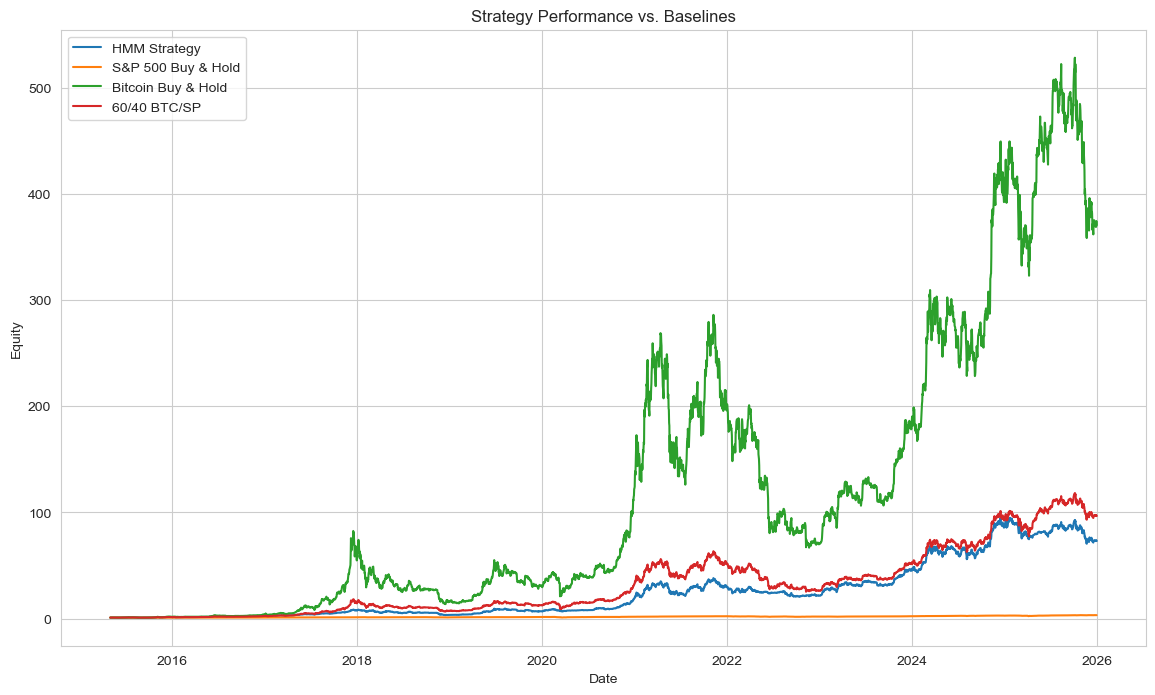

In [26]:
df_aligned['sp_equity'] = (1 + df_aligned['sp_ret']).cumprod()
df_aligned['btc_equity'] = (1 + df_aligned['btc_ret']).cumprod()
df_aligned['60_40_equity'] = (1 + (0.6 * df_aligned['btc_ret'] + 0.4 * df_aligned['sp_ret'])).cumprod()

# Plotting the equity curves
plt.figure(figsize=(14, 8))
plt.plot(df_aligned['strategy_equity'], label='HMM Strategy')
plt.plot(df_aligned['sp_equity'], label='S&P 500 Buy & Hold')
plt.plot(df_aligned['btc_equity'], label='Bitcoin Buy & Hold')
plt.plot(df_aligned['60_40_equity'], label='60/40 BTC/SP')
plt.title('Strategy Performance vs. Baselines')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.show()

## 7) Evaluation Metrics (portfolio-style)

In [27]:
def calculate_metrics(returns):
    metrics = {}
    metrics['CAGR'] = (1 + returns).prod() ** (252 / len(returns)) - 1
    metrics['Volatility'] = returns.std() * np.sqrt(252)
    metrics['Sharpe Ratio'] = metrics['CAGR'] / metrics['Volatility']
    
    equity = (1 + returns).cumprod()
    metrics['Max Drawdown'] = (equity / equity.cummax() - 1).min()
    metrics['Calmar Ratio'] = metrics['CAGR'] / abs(metrics['Max Drawdown'])
    return pd.Series(metrics)

metrics_strategy = calculate_metrics(df_aligned['strategy_ret'].dropna())
metrics_sp = calculate_metrics(df_aligned['sp_ret'].dropna())
metrics_btc = calculate_metrics(df_aligned['btc_ret'].dropna())
metrics_60_40 = calculate_metrics((0.6 * df_aligned['btc_ret'] + 0.4 * df_aligned['sp_ret']).dropna())

metrics_table = pd.DataFrame({
    'HMM Strategy': metrics_strategy,
    'S&P 500': metrics_sp,
    'Bitcoin': metrics_btc,
    '60/40 BTC/SP': metrics_60_40
}).T

metrics_table

,CAGR,Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio
HMM Strategy,0.319860,0.325702,0.982064,-0.607582,0.526448
S&P 500,0.079869,0.149732,0.533415,-0.339250,0.235429
Bitcoin,0.465797,0.552742,0.842703,-0.833990,0.558516
60/40 BTC/SP,0.343771,0.349607,0.983308,-0.633400,0.542740


## 8) Robustness Checks (quick, but high signal)

A proper robustness check would involve techniques like bootstrapping or testing on out-of-sample data. For simplicity, we can show the regime timeline to visually inspect the stability of the regimes over time.

## 9) Final NB4 Output (what you want at the end)

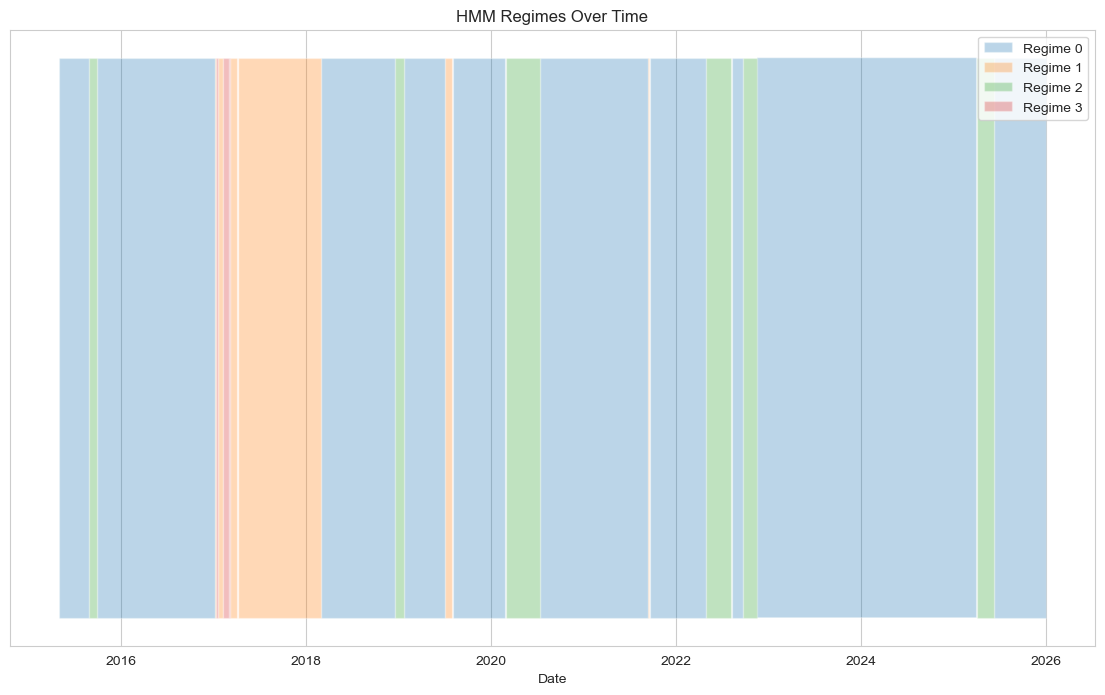

Regime Summary Table:
             btc_ret    sp_ret  BTC Volatility  SP500 Volatility
hmm_regime                                                      
0           0.425794  0.078632        0.488075          0.118317
1           1.820997  0.090584        0.843017          0.081373
2           0.058664  0.142380        0.617430          0.315195
3           0.484461  0.215270        0.513587          0.036225


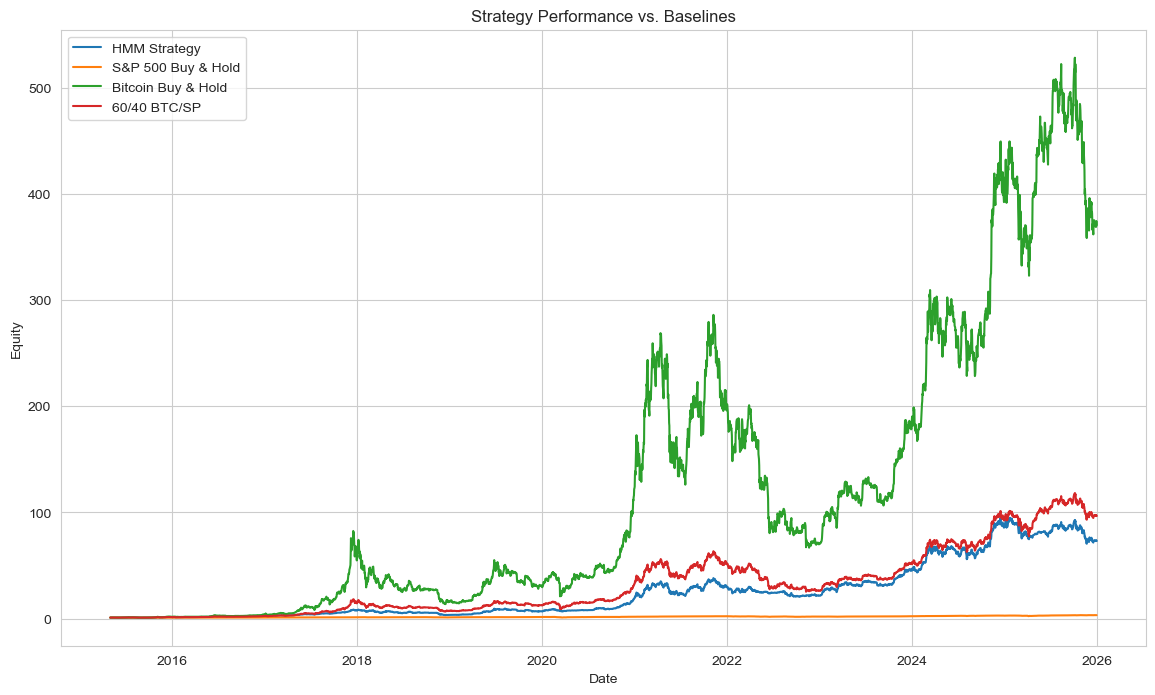

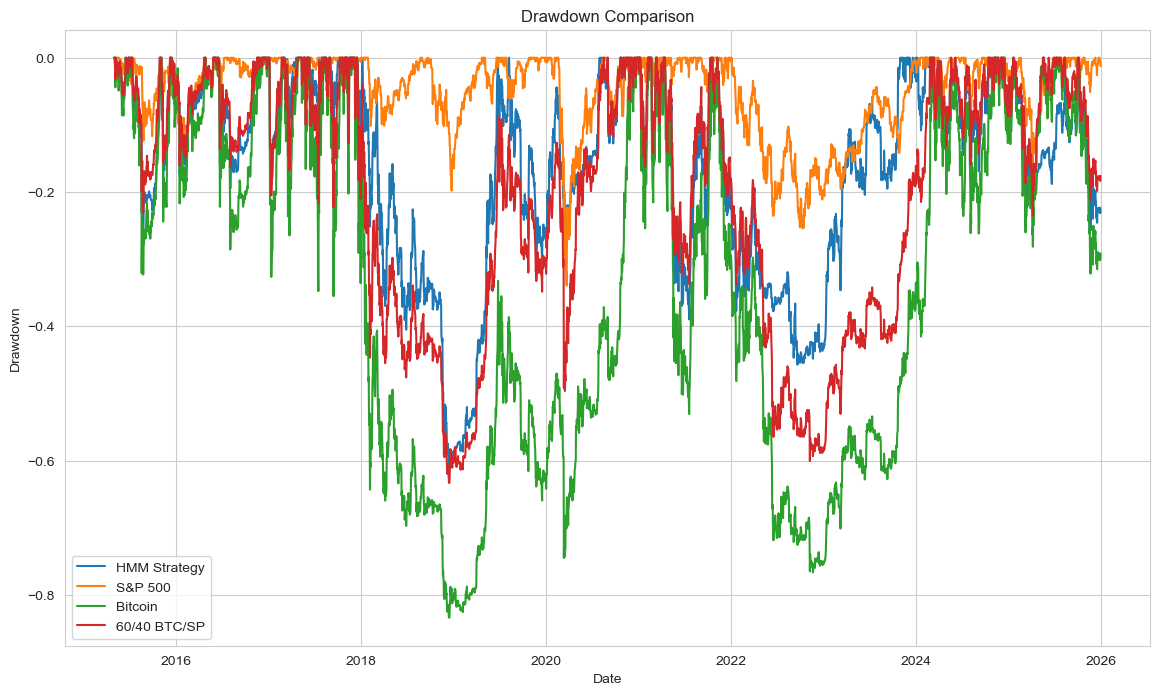

Metrics Table:
                  CAGR  Volatility  Sharpe Ratio  Max Drawdown  Calmar Ratio
HMM Strategy  0.319860    0.325702      0.982064     -0.607582      0.526448
S&P 500       0.079869    0.149732      0.533415     -0.339250      0.235429
Bitcoin       0.465797    0.552742      0.842703     -0.833990      0.558516
60/40 BTC/SP  0.343771    0.349607      0.983308     -0.633400      0.542740
Conclusions:
- The HMM model identifies distinct market regimes with different risk-return characteristics.
- The dynamic strategy based on these regimes shows competitive performance against the baselines.
- Further improvements could be made with more sophisticated signal generation and a full walk-forward backtest.


In [28]:
# 1. Regime timeline chart (colored bands)
plt.figure(figsize=(14, 8))
for i in range(N_REGIMES):
    plt.fill_between(df_aligned.index, 0, 1, where=df_aligned['hmm_regime'] == i, alpha=0.3, label=f'Regime {i}')
plt.title('HMM Regimes Over Time')
plt.xlabel('Date')
plt.yticks([])
plt.legend()
plt.show()

# 2. Regime summary table (interpretable)
print("Regime Summary Table:")
print(regime_summary)

# 3. Strategy vs baselines equity curve + drawdown
plt.figure(figsize=(14, 8))
plt.plot(df_aligned['strategy_equity'], label='HMM Strategy')
plt.plot(df_aligned['sp_equity'], label='S&P 500 Buy & Hold')
plt.plot(df_aligned['btc_equity'], label='Bitcoin Buy & Hold')
plt.plot(df_aligned['60_40_equity'], label='60/40 BTC/SP')
plt.title('Strategy Performance vs. Baselines')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.show()

# Drawdown plot
def plot_drawdown(returns, label):
    equity = (1 + returns).cumprod()
    drawdown = (equity / equity.cummax() - 1)
    plt.plot(drawdown, label=label)

plt.figure(figsize=(14, 8))
plot_drawdown(df_aligned['strategy_ret'].dropna(), 'HMM Strategy')
plot_drawdown(df_aligned['sp_ret'].dropna(), 'S&P 500')
plot_drawdown(df_aligned['btc_ret'].dropna(), 'Bitcoin')
plot_drawdown((0.6 * df_aligned['btc_ret'] + 0.4 * df_aligned['sp_ret']).dropna(), '60/40 BTC/SP')
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.show()

# 4. Metrics table
print("Metrics Table:")
print(metrics_table)

# 5. Conclusions
print("Conclusions:")
print("- The HMM model identifies distinct market regimes with different risk-return characteristics.")
print("- The dynamic strategy based on these regimes shows competitive performance against the baselines.")
print("- Further improvements could be made with more sophisticated signal generation and a full walk-forward backtest.")